In [68]:
def evaluate_classifier_with_noise(df_positive, df_negative, noise_scale=10, pos_label=1, neg_label=0, title_suffix=""):
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    import seaborn as sns
    from sklearn.ensemble import RandomForestClassifier
    from sklearn.model_selection import cross_val_predict
    from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc

    # Labels setzen
    df_positive = df_positive.copy()
    df_negative = df_negative.copy()
    df_positive['Label'] = pos_label
    df_negative['Label'] = neg_label

    # Rauschen hinzufügen
    df_positive['z-score calculated from 7. 8. and 9.'] += np.random.normal(loc=0, scale=noise_scale, size=len(df_positive))
    df_negative['z-score calculated from 7. 8. and 9.'] += np.random.normal(loc=0, scale=noise_scale, size=len(df_negative))

    # Kombinieren
    data = pd.concat([df_positive, df_negative], ignore_index=True)

    # Visualisierung
    sns.histplot(data=data, x='z-score calculated from 7. 8. and 9.', hue='Label', kde=True, bins=50)
    plt.title(f"Verteilung der z-Scores mit Rauschen {title_suffix}")
    plt.xlabel("z-Score")
    plt.ylabel("Anzahl")
    plt.show()

    # Vorbereitung
    X = data[['z-score calculated from 7. 8. and 9.']]
    y = data['Label']
    model = RandomForestClassifier(n_estimators=100, random_state=42)

    # Cross-Validation
    y_pred = cross_val_predict(model, X, y, cv=5, method='predict')
    y_proba = cross_val_predict(model, X, y, cv=5, method='predict_proba')[:, 1]

    # Auswertung
    print("🔹 Confusion Matrix:\n", confusion_matrix(y, y_pred))
    print("\n🔹 Classification Report:\n", classification_report(y, y_pred))

    # ROC
    fpr, tpr, thresholds = roc_curve(y, y_proba)
    roc_auc = auc(fpr, tpr)

    # Plot ROC
    plt.figure()
    plt.plot(fpr, tpr, label=f"ROC (AUC = {roc_auc:.2f})", color='red')
    plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC-Kurve {title_suffix}")
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.show()


In [69]:
import pandas as pd

# Load the data
df_sissi = pd.read_excel("D:/Masterarbeit_programmieren/2.Versuch/Data/SISSIz_Excel/sissi.xlsx", usecols=['z-score calculated from 7. 8. and 9.'])
df_sissiz_mono = pd.read_excel("D:/Masterarbeit_programmieren/2.Versuch/Data/SISSIz_Excel/sissiz_mono.xlsx", usecols=['z-score calculated from 7. 8. and 9.'])
df_sissiz_di = pd.read_excel("D:/Masterarbeit_programmieren/2.Versuch/Data/SISSIz_Excel/sissiz_di.xlsx", usecols=['z-score calculated from 7. 8. and 9.'])
df_multiperm_mono = pd.read_excel("D:/Masterarbeit_programmieren/2.Versuch/Data/SISSIz_Excel/multiperm_mono.xlsx", usecols=['z-score calculated from 7. 8. and 9.'])
df_multiperm_di = pd.read_excel("D:/Masterarbeit_programmieren/2.Versuch/Data/SISSIz_Excel/multiperm_di.xlsx", usecols=['z-score calculated from 7. 8. and 9.'])
df_aln_shuffle = pd.read_excel("D:/Masterarbeit_programmieren/2.Versuch/Data/SISSIz_Excel/alifoldz.xlsx", usecols=['z-score calculated from 7. 8. and 9.'])

noise_scale_for_all=5

## SISSIz_MONO

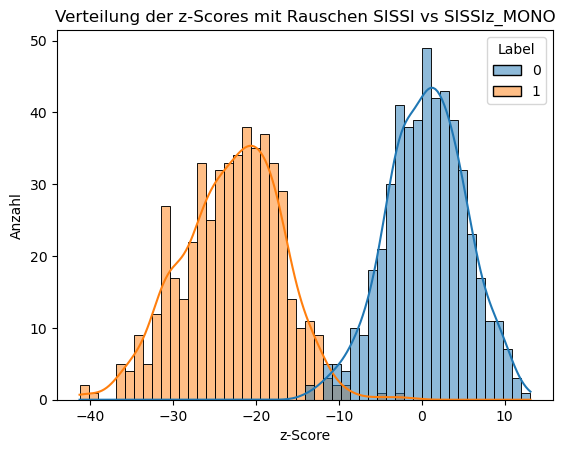

🔹 Confusion Matrix:
 [[492   8]
 [  9 491]]

🔹 Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.98      0.98       500
           1       0.98      0.98      0.98       500

    accuracy                           0.98      1000
   macro avg       0.98      0.98      0.98      1000
weighted avg       0.98      0.98      0.98      1000



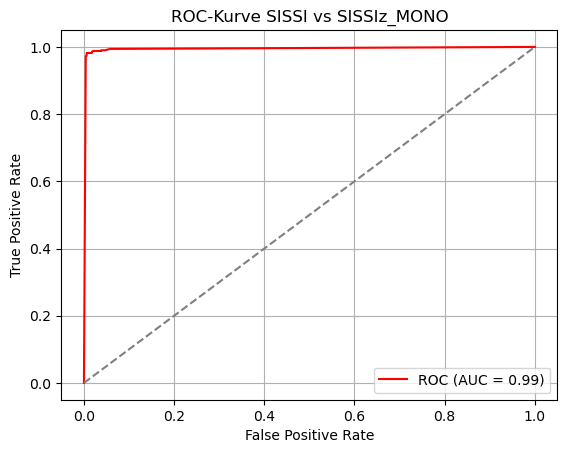

In [70]:
evaluate_classifier_with_noise(df_sissi, df_sissiz_mono, noise_scale=noise_scale_for_all, title_suffix="SISSI vs SISSIz_MONO")

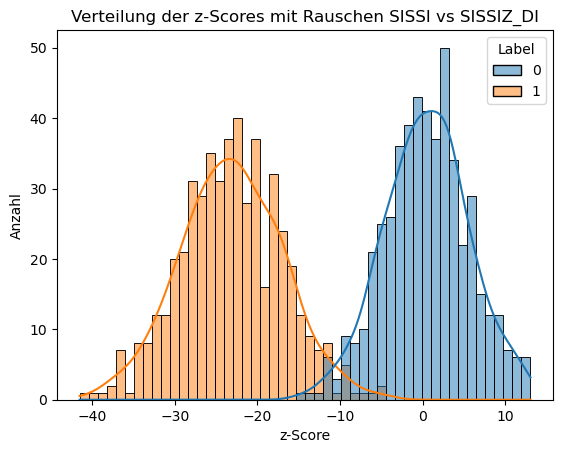

🔹 Confusion Matrix:
 [[484  16]
 [ 16 484]]

🔹 Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.97      0.97       500
           1       0.97      0.97      0.97       500

    accuracy                           0.97      1000
   macro avg       0.97      0.97      0.97      1000
weighted avg       0.97      0.97      0.97      1000



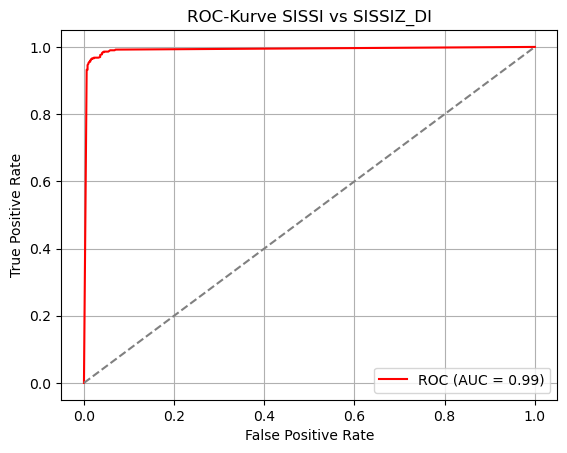

In [71]:
# Beispiel mit sissi vs multiperm_di
evaluate_classifier_with_noise(df_sissi, df_sissiz_di, noise_scale=noise_scale_for_all, title_suffix="SISSI vs SISSIZ_DI")

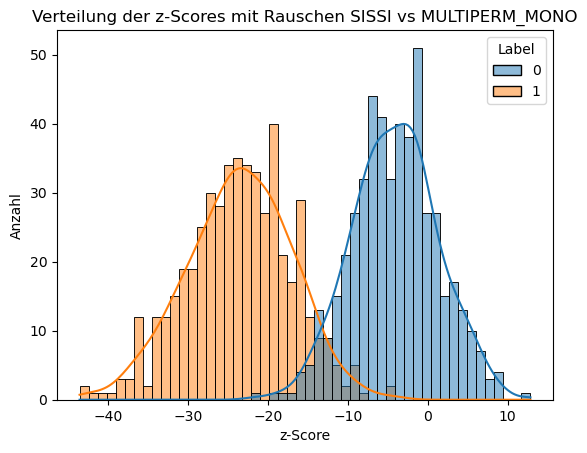

🔹 Confusion Matrix:
 [[464  36]
 [ 33 467]]

🔹 Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.93      0.93       500
           1       0.93      0.93      0.93       500

    accuracy                           0.93      1000
   macro avg       0.93      0.93      0.93      1000
weighted avg       0.93      0.93      0.93      1000



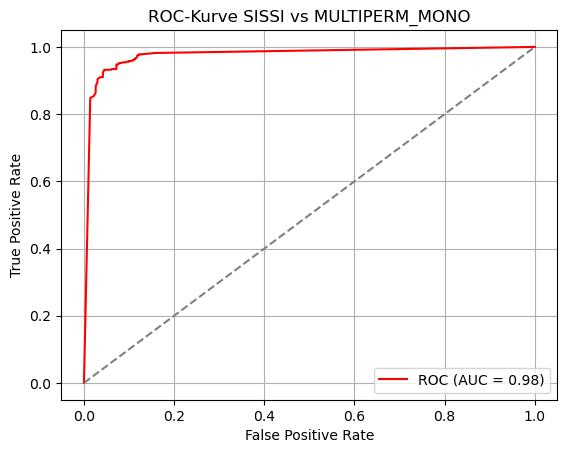

In [72]:
evaluate_classifier_with_noise(df_sissi, df_multiperm_mono, noise_scale=noise_scale_for_all, title_suffix="SISSI vs MULTIPERM_MONO")

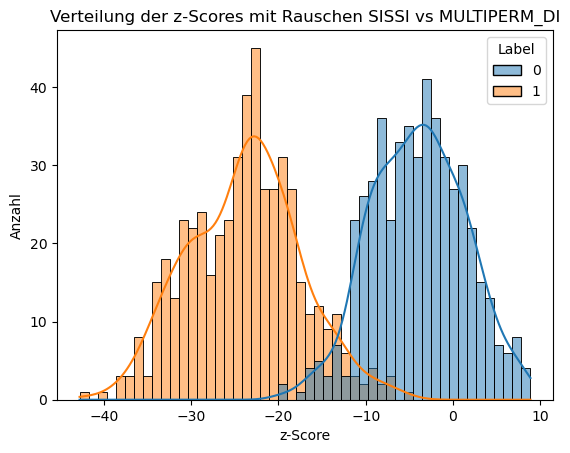

🔹 Confusion Matrix:
 [[469  31]
 [ 34 466]]

🔹 Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.94      0.94       500
           1       0.94      0.93      0.93       500

    accuracy                           0.94      1000
   macro avg       0.94      0.94      0.93      1000
weighted avg       0.94      0.94      0.93      1000



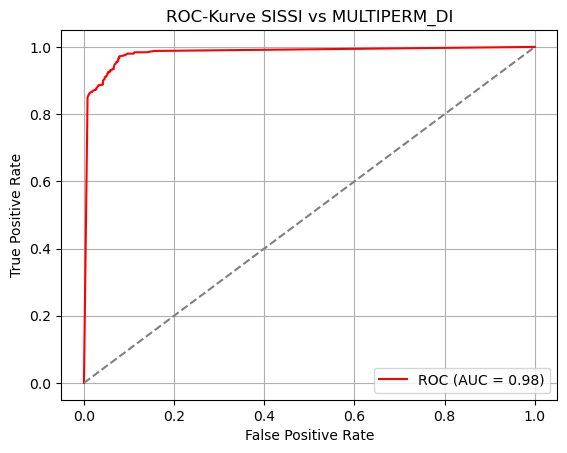

In [73]:
evaluate_classifier_with_noise(df_sissi, df_multiperm_di, noise_scale=noise_scale_for_all, title_suffix="SISSI vs MULTIPERM_DI")

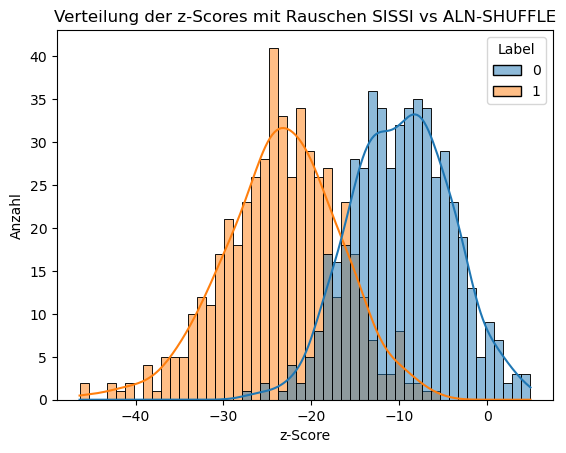

🔹 Confusion Matrix:
 [[403  97]
 [ 82 418]]

🔹 Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.81      0.82       500
           1       0.81      0.84      0.82       500

    accuracy                           0.82      1000
   macro avg       0.82      0.82      0.82      1000
weighted avg       0.82      0.82      0.82      1000



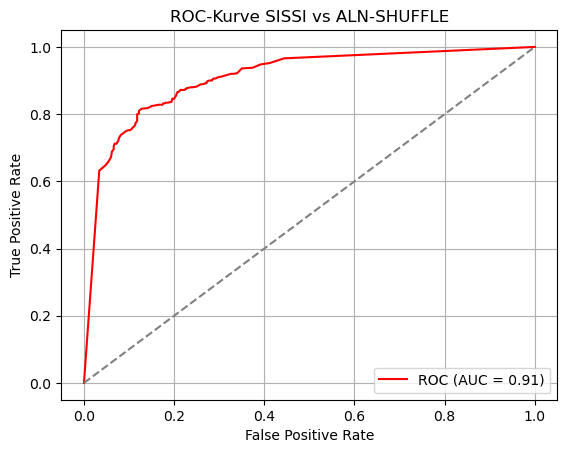

In [74]:
evaluate_classifier_with_noise(df_sissi, df_aln_shuffle, noise_scale=noise_scale_for_all, title_suffix="SISSI vs ALN-SHUFFLE")